In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

**Importing the dataset "ADVERTISING.CSV"**

In [15]:
df = pd.read_csv('https://raw.githubusercontent.com/nguyen-toan/ISLR/refs/heads/master/dataset/Advertising.csv')
print(df)

     Unnamed: 0     TV  Radio  Newspaper  Sales
0             1  230.1   37.8       69.2   22.1
1             2   44.5   39.3       45.1   10.4
2             3   17.2   45.9       69.3    9.3
3             4  151.5   41.3       58.5   18.5
4             5  180.8   10.8       58.4   12.9
..          ...    ...    ...        ...    ...
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4

[200 rows x 5 columns]


 # ***DATASET INSPECTION & EXPLORATION***


In [35]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


**This initial view of the dataset confirms its structure: each entry provides a set of advertising budgets across three different media, along with the corresponding sales outcome for that observation.**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


**the DataFrame has 200 entries and 4 columns, with no missing values and all columns storing numerical data as float64.**

In [25]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

**This means that there are no missing values**

In [26]:
df.corr()

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


In [8]:
df.duplicated().sum()

0

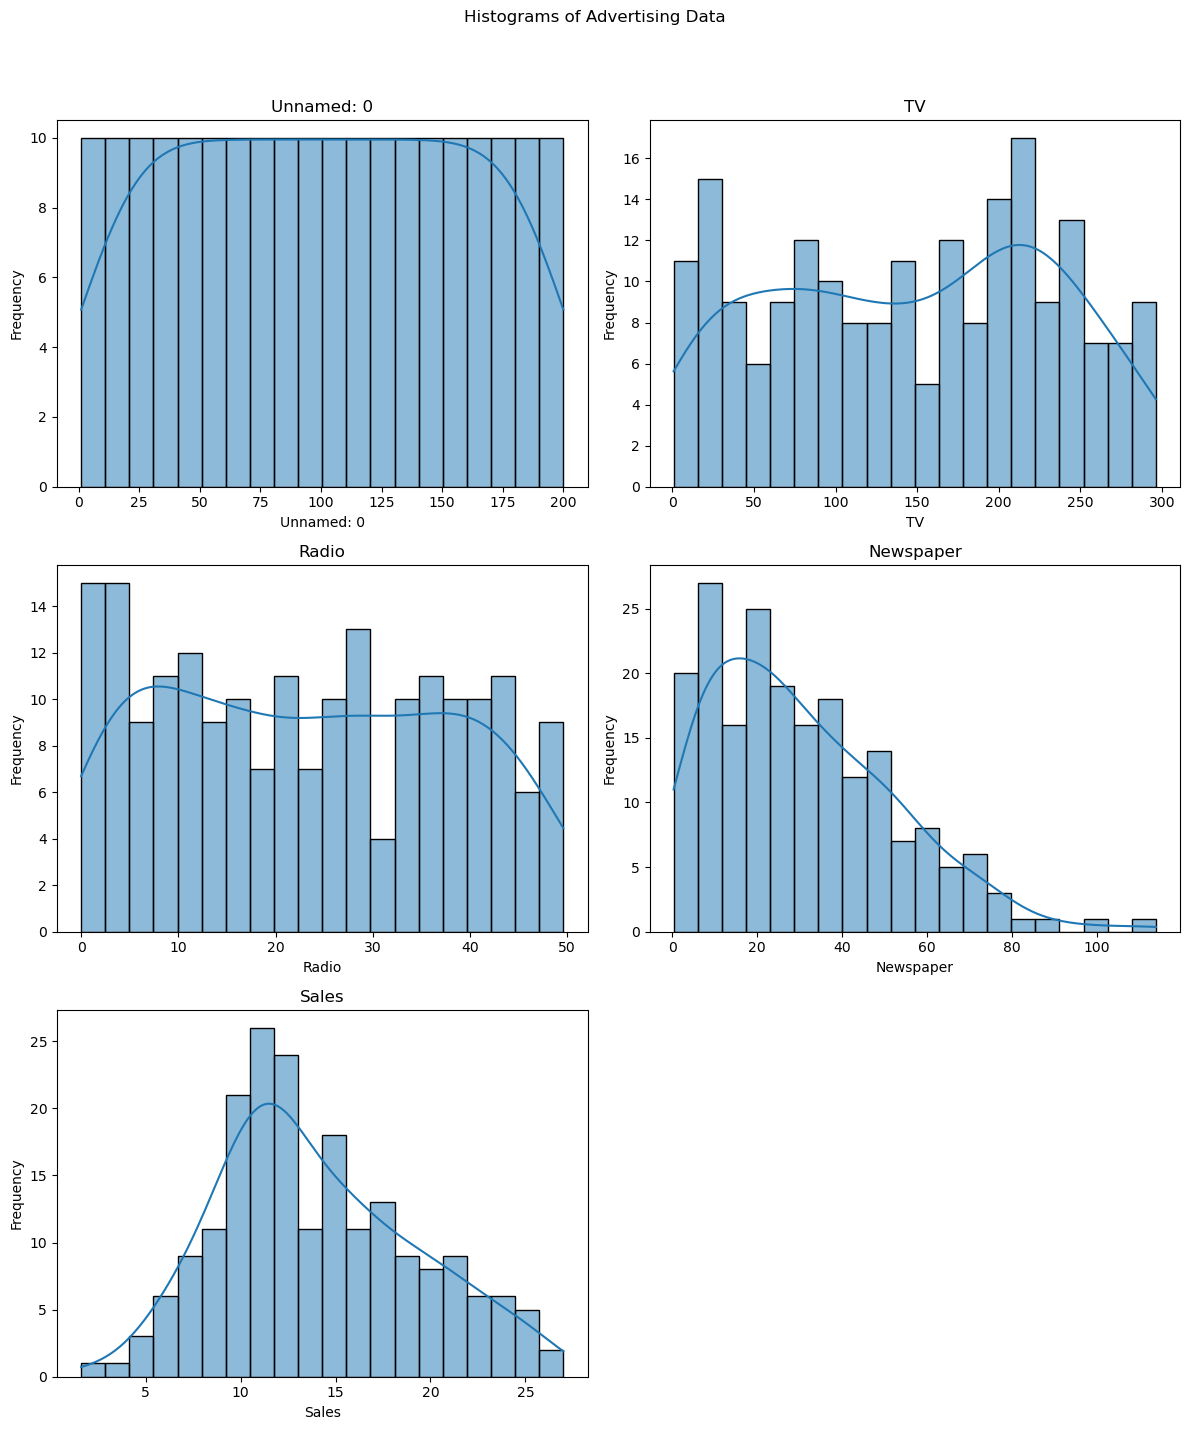

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
df = pd.read_csv('https://raw.githubusercontent.com/nguyen-toan/ISLR/refs/heads/master/dataset/Advertising.csv') 
num_cols = len(df.columns)
num_rows = math.ceil(num_cols / 2)
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 5 * num_rows))
fig.suptitle('Histograms of Advertising Data')
axes = axes.ravel()
for i, col in enumerate(df.columns):
    sns.histplot(df[col], bins=20, edgecolor='black', ax=axes[i], kde=True)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**These histograms visually represent the distribution of values for `TV`, `Radio`, `Newspaper`, and `Sales`. This helps to identify whether the data is normally distributed, skewed, or contains outliers for each variable.**

## Univariate Exploration

In [18]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


**The descriptive statistics show that TV ad spending was highest on average and most variable, followed by Newspaper and then Radio. The average sales figure was approximately 15.13, and spending across all three channels exhibited a wide range.**

## Bivariate Exploration

In [19]:
df.corr()

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


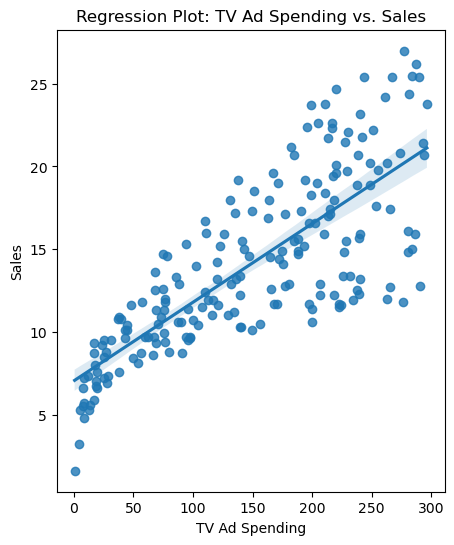

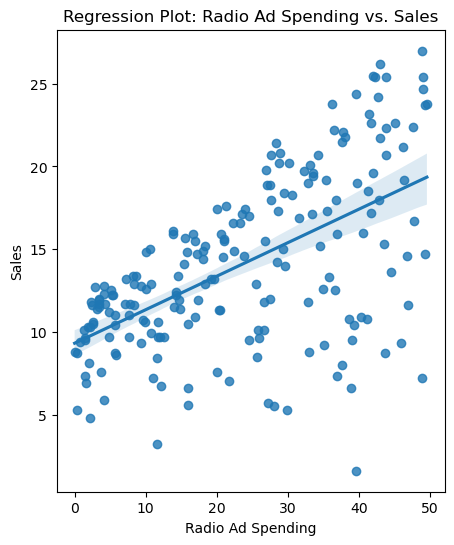

In [54]:
df = pd.read_csv('https://raw.githubusercontent.com/nguyen-toan/ISLR/refs/heads/master/dataset/Advertising.csv')

# TV vs. Sales
plt.figure(figsize=(5, 6))
sns.regplot(x='TV', y='Sales', data=df)
plt.title('Regression Plot: TV Ad Spending vs. Sales')
plt.xlabel('TV Ad Spending')
plt.ylabel('Sales')
plt.show()

# Radio vs. Sales
plt.figure(figsize=(5, 6))
sns.regplot(x='Radio', y='Sales', data=df)
plt.title('Regression Plot: Radio Ad Spending vs. Sales')
plt.xlabel('Radio Ad Spending')
plt.ylabel('Sales')
plt.show()

**Based on our data exploration, the advertising dataset reveals that TV advertising is the most effective channel for generating sales, followed by radio, while newspaper advertising has a negligible impact.**

## Multivariate Exploration

C:\Users\Acer\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


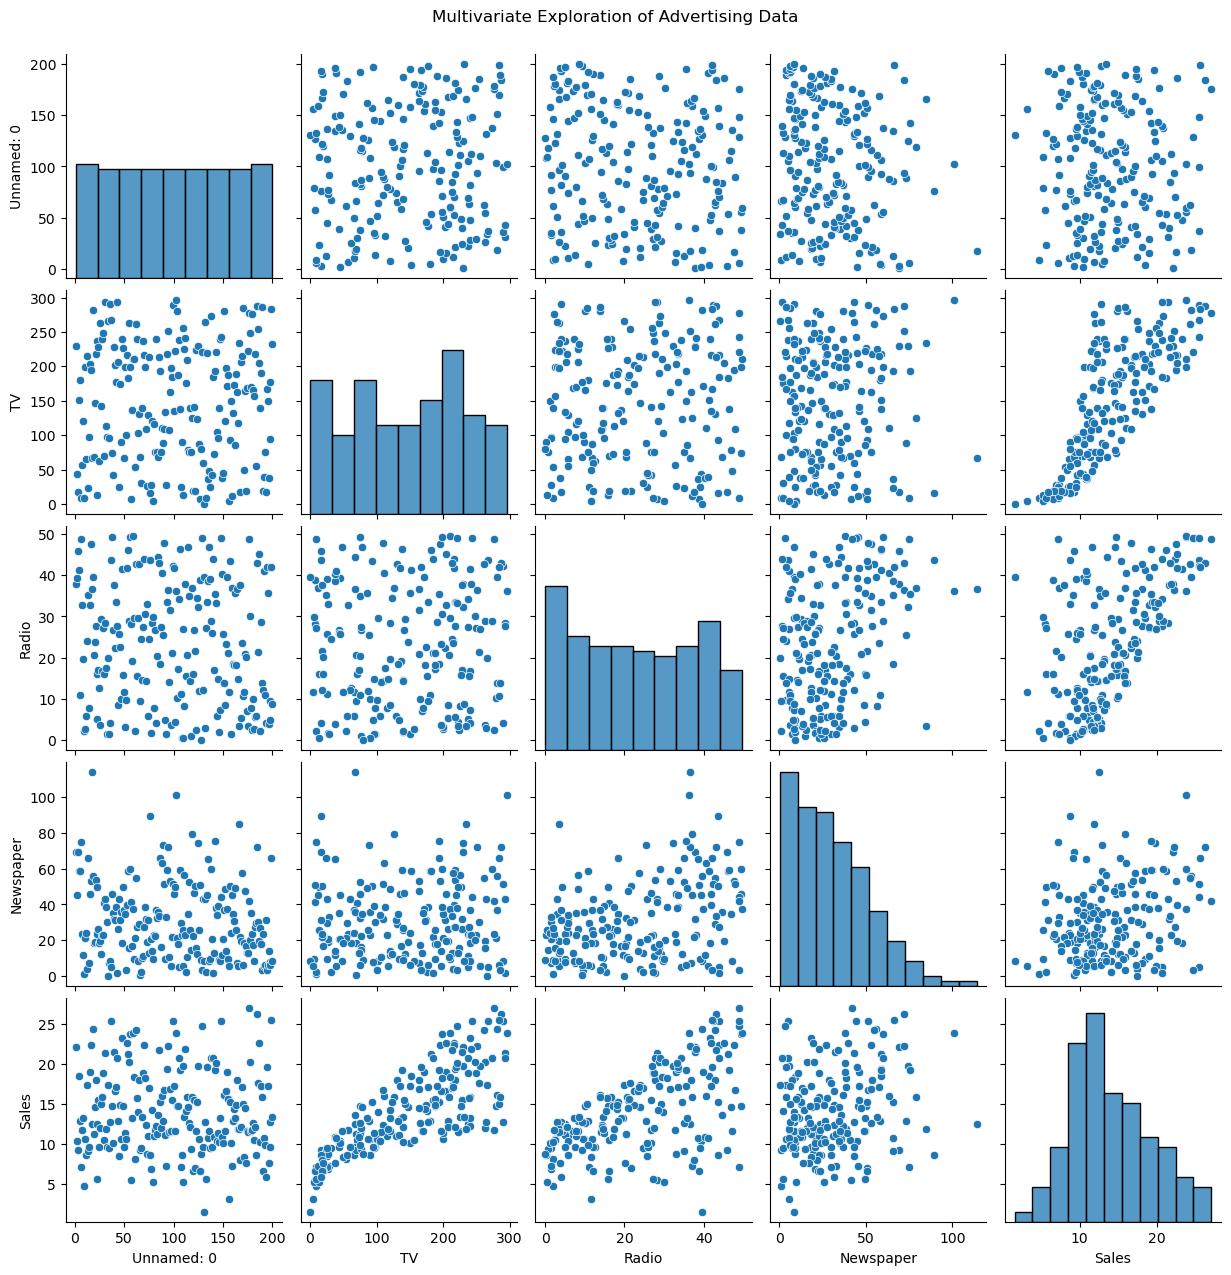

In [57]:
sns.pairplot(df)
plt.suptitle('Multivariate of Advertising Data', y=1.02)
plt.show()

**Based on the box plots, the data shows that spending on **TV and Radio** is widely distributed without any clear outliers. In contrast, **Newspaper** spending is heavily concentrated at lower values, with a few exceptionally high-spending outliers. The `Sales` data is tightly clustered around the median, indicating a narrow range of outcomes without any unusual extremes.**